# BABILong RMM v5p7 — results collection

Scans `runs-rmmv5p7/babilong2/**` for finished runs (`config.json` + `all_results.json`) and builds:
- a tidy dataframe of every result,
- **length-extrapolation** pivots (from the `eval_seg<N>_from<SRC>` sweeps),
- **training-curriculum** pivots (per-stage best eval from the `seg<N>_from<M>` runs),
- GitHub-markdown tables + CSV written next to this notebook.
- **`results_babilong_comparison.csv`**: published BABILong qa1–qa3 table (Mamba / RMT / ARMT / RMM vs context length). The RMM rows are **derived from the `src=32` evals below**, not hardcoded.

> **`babilong2` = the bug-fixed segmentation.** The `babilong/` runs used the old
> collate, which put question+answer in a dedicated *extra* segment; the fix
> (`run_rmm_on_babilong-v5p7.py`, commit *fix babilong segmentation*) splits the
> flat `input + question + target` sequence into `ceil(len/segment_size)` uniform
> segments so the question+answer ride in the **last context segment**, exactly like
> the RMT reference. The two are not comparable — this notebook reads `babilong2`
> only. Checkpoints from `babilong2` must likewise only ever be evaluated with the
> fixed runner (`scripts/babilong/eval_babilong2_seg32.py` does this).

Runs whether launched from `notebooks/` or the repo root. Crashed/in-progress runs (no `all_results.json`) are skipped.

Set **`TABLE_MAX_LENGTH`** (first code cell, default `'128K'`) to cap context columns in all pivots and the benchmark table.

> Note: eval runs are launched without `--learning_rate`, so the eval `config.json` records the runner's default LR, **not** the trained model's. The real LR (and the model identity) is parsed from the `RUN_NAME` in the path.

In [21]:
import json, glob, re
from pathlib import Path
import numpy as np
import pandas as pd

# repo root: works whether this notebook is run from notebooks/ or the repo root
CWD = Path.cwd()
REPO = CWD if (CWD / 'runs-rmmv5p7').exists() else CWD.parent
# babilong2 = runs produced with the FIXED segmentation (question+answer in the
# last context segment). Do not mix with the old 'babilong' tree.
RUNS_SUBDIR = 'babilong2'
RUN_GLOB = f'runs-rmmv5p7/{RUNS_SUBDIR}/**/config.json'
# Max context in exported/displayed tables ('128K', '512K', '10M', or None = full range)
TABLE_MAX_LENGTH = '512K'
# Eval batch size the BENCHMARK table is built from. collate_babilong sets the
# segment count S from the LONGEST sequence in the batch, so bs changes how many
# all-pad segments the recurrence sees before the real content -- bs=1 and bs=8
# are different measurements and must never be pooled into one cell.
BENCH_BS = 8
assert (REPO / 'runs-rmmv5p7' / RUNS_SUBDIR).exists(), f'runs-rmmv5p7/{RUNS_SUBDIR} not found under {REPO}'
print('repo root:', REPO, '| runs:', RUNS_SUBDIR, '| table max length:', TABLE_MAX_LENGTH)

repo root: /home/bulatov/rmt/test-time/compressing-associations-gdn | runs: babilong2 | table max length: 512K


In [22]:
def collect(repo):
    rows = []
    for cfg in glob.glob(str(repo / RUN_GLOB), recursive=True):
        d = Path(cfg).parent
        res = d / 'all_results.json'
        if not res.exists():
            continue  # crashed / in-progress run
        c = json.load(open(cfg)).get('cli_args', {})
        r = json.load(open(res))
        ep = Path(c.get('exp_path', str(d)))
        leaf, run_name = ep.parts[-2], ep.parts[-3]
        m = re.match(r'(eval_)?seg(\d+)_from(\d+)', leaf)
        # trained LR lives in RUN_NAME (eval runs don't pass --learning_rate)
        lr_m = re.search(r'_lr([0-9.e+-]+)_bs', run_name)
        rows.append(dict(
            task=c.get('task_dataset', '?').split('_')[0],
            write=c.get('write_mode'), read=c.get('read_mode'),
            mem=c.get('num_memory_vectors'), ss=c.get('state_size'),
            bs=c.get('per_device_batch_size'),
            lr=lr_m.group(1) if lr_m else '?',
            kind='eval' if leaf.startswith('eval_') else 'train',
            seg=int(m.group(2)) if m else np.nan,
            src=int(m.group(3)) if m else np.nan,
            exact_match=r.get('eval_exact_match'),
            token_acc=r.get('eval_token_accuracy'),
            run_name=run_name, path=str(ep),
        ))
    df = pd.DataFrame(rows)
    if len(df):
        df['variant'] = (df.write + '/' + df.read + ' mem' + df.mem.astype(str)
                         + ' ss' + df.ss.astype(str) + ' lr' + df.lr)
        df = df.sort_values(['task', 'variant', 'kind', 'seg']).reset_index(drop=True)
    return df

df = collect(REPO)
print(f'{len(df)} results  ({(df.kind == "eval").sum()} eval, {(df.kind == "train").sum()} train)')
df[['task', 'variant', 'kind', 'src', 'seg', 'exact_match', 'token_acc']]

144 results  (57 eval, 87 train)


,task,variant,kind,src,seg,exact_match,token_acc
0,qa1,identity/identity mem16 ss32 lr1e-03,eval,32,1,1.000000,1.000000
1,qa1,identity/identity mem16 ss32 lr1e-03,eval,32,2,1.000000,1.000000
2,qa1,identity/identity mem16 ss32 lr1e-03,eval,32,4,1.000000,1.000000
3,qa1,identity/identity mem16 ss32 lr1e-03,eval,32,8,1.000000,1.000000
4,qa1,identity/identity mem16 ss32 lr1e-03,eval,32,16,1.000000,1.000000
...,...,...,...,...,...,...,...
139,qa3,pool/unpool mem16 ss32 lr3e-04,train,0,1,0.992993,0.995909
140,qa3,pool/unpool mem16 ss32 lr3e-04,train,1,2,0.974975,0.985389
141,qa3,pool/unpool mem16 ss32 lr3e-04,train,2,4,0.945946,0.968440
142,qa3,pool/unpool mem16 ss32 lr3e-04,train,4,6,0.920921,0.953828


In [23]:
def show(pivot):
    """Styler with a red->green heatmap; degrades gracefully if matplotlib is absent."""
    s = pivot.style.format('{:.3f}', na_rep='\u2014')
    try:
        s = s.background_gradient(cmap='RdYlGn', vmin=0.0, vmax=1.0, axis=None)
    except Exception:
        pass
    return s

def seg_label(n):
    """Map segment count to context length (512 tok/seg): seg1 -> 0.5k, seg2 -> 1k, ..."""
    return f'{int(n) * 0.5:g}k'

# The published BABILong grid, used as the POSITIONAL index for the
# literature rows below -- do not reorder or insert into this one.
LIT_CONTEXT_COLS = ['0K', '1K', '2K', '4K', '8K', '16K', '32K', '64K', '128K', '512K', '1M', '10M']
# Our own sweep adds 256K (512 segments), which the published grid skips.
ALL_BENCH_CONTEXT_COLS = ['0K', '1K', '2K', '4K', '8K', '16K', '32K', '64K',
                          '128K', '256K', '512K', '1M', '10M']

def _bench_col_to_k(label):
    s = str(label).strip().upper()
    if s.endswith('K'):
        return float(s[:-1])
    if s.endswith('M'):
        return float(s[:-1]) * 1000
    raise ValueError(f'unknown context label: {label!r}')

def bench_context_cols(max_len=TABLE_MAX_LENGTH):
    if max_len is None:
        return list(ALL_BENCH_CONTEXT_COLS)
    max_k = _bench_col_to_k(max_len)
    return [c for c in ALL_BENCH_CONTEXT_COLS if _bench_col_to_k(c) <= max_k]

def _seg_col_to_k(label):
    return float(str(label).lower().rstrip('k'))

def clip_pivot_to_max_length(pivot, max_len=TABLE_MAX_LENGTH):
    if pivot is None or max_len is None:
        return pivot
    max_k = _bench_col_to_k(max_len)
    keep = [c for c in pivot.columns if _seg_col_to_k(c) <= max_k]
    return pivot.loc[:, keep]

def to_md(pivot, fmt='{:.3f}'):
    """GitHub-markdown table from a pivot (dependency-free; no tabulate needed)."""
    p = pivot.reset_index()
    cols = [str(c) for c in p.columns]
    lines = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join('---' for _ in cols) + '|']
    for _, row in p.iterrows():
        cells = []
        for v in row:
            if isinstance(v, float) and pd.isna(v):
                cells.append('')
            elif isinstance(v, float):
                cells.append(fmt.format(v))
            else:
                cells.append(str(v))
        lines.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join(lines)

## Length-extrapolation eval

Rows = trained variant + source curriculum length (`src`); columns = eval segment count. Values = exact_match.

In [24]:
ev = df[df.kind == 'eval']
eval_em = eval_acc = None
if len(ev):
    eval_em = ev.pivot_table(index=['task', 'variant', 'src', 'bs'], columns='seg', values='exact_match')
    eval_acc = ev.pivot_table(index=['task', 'variant', 'src', 'bs'], columns='seg', values='token_acc')
    eval_em.columns = eval_acc.columns = [seg_label(c) for c in eval_em.columns]
    eval_em = clip_pivot_to_max_length(eval_em)
    eval_acc = clip_pivot_to_max_length(eval_acc)
print('exact_match')
show(eval_em) if eval_em is not None else print('(no eval runs yet)')

exact_match


In [25]:
(eval_em * 100).round(1)

0.5k     1k     2k     4k  \
task variant                              src                               
qa1  identity/identity mem16 ss32 lr1e-03 32   100.0  100.0  100.0  100.0   
     identity/identity mem16 ss32 lr1e-04 32   100.0  100.0  100.0  100.0   
     identity/identity mem16 ss32 lr3e-04 32   100.0  100.0  100.0  100.0   
     pool/unpool mem16 ss32 lr1e-04       32    99.9   99.9  100.0   99.9   
qa2  identity/identity mem16 ss32 lr1e-04 32   100.0  100.0   99.9  100.0   
     identity/identity mem16 ss32 lr3e-04 32   100.0  100.0  100.0  100.0   

                                                  8k    16k    32k    64k  \
task variant                              src                               
qa1  identity/identity mem16 ss32 lr1e-03 32   100.0  100.0   99.1   98.0   
     identity/identity mem16 ss32 lr1e-04 32   100.0  100.0  100.0  100.0   
     identity/identity mem16 ss32 lr3e-04 32    99.9  100.0   99.9   99.8   
     pool/unpool mem16 ss32 lr1e-04       32   100.0   99.9   99.6   99.6   
qa2  identity/identity mem16 ss32 lr1e-04 32    99.9  100.0   99.6   97.8   
     identity/identity mem16 ss32 lr3e-04 32   100.0  100.0   99.9   99.6   

                                               128k  256k  
task variant                              src              
qa1  identity/identity mem16 ss32 lr1e-03 32   94.8   NaN  
     identity/identity mem16 ss32 lr1e-04 32   97.1  83.8  
     identity/identity mem16 ss32 lr3e-04 32   97.7   NaN  
     pool/unpool mem16 ss32 lr1e-04       32   97.1  86.2  
qa2  identity/identity mem16 ss32 lr1e-04 32   94.2   NaN  
     identity/identity mem16 ss32 lr3e-04 32   94.1  77.4

In [26]:
print('token_accuracy')
show(eval_acc) if eval_acc is not None else print('(no eval runs yet)')

token_accuracy


## Training curriculum (per-stage best eval)

Rows = variant; columns = trained stage length; values = exact_match at the end of that stage.

In [27]:
tr = df[df.kind == 'train']
train_em = None
if len(tr):
    train_em = tr.pivot_table(index=['task', 'variant'], columns='seg', values='exact_match')
    train_em.columns = [seg_label(c) for c in train_em.columns]
    train_em = clip_pivot_to_max_length(train_em)
show(train_em) if train_em is not None else print('(no training runs yet)')

## BABILong benchmark comparison (qa1–qa3)

Literature baselines (Mamba, RMT, ARMT) plus reported RMM numbers at **mem update** 1 or 512 tokens. Columns are context length (capped at `TABLE_MAX_LENGTH`); values are **exact-match accuracy (%)**.

In [28]:
CONTEXT_COLS = bench_context_cols()

def bench_row(task, method, mem, vals):
    """`vals` are positional against LIT_CONTEXT_COLS (the published grid), so
    adding our own 256K column never shifts a published number."""
    row = {'task': task, 'method': method, 'mem_update_tokens': mem}
    row.update({c: None for c in ALL_BENCH_CONTEXT_COLS})
    for i, col in enumerate(LIT_CONTEXT_COLS):
        if i < len(vals):
            row[col] = vals[i]
    return row

# Published BABILong numbers (% exact match); empty cells are missing evals.
LIT_ROWS = [
    bench_row('qa1', 'Mamba', 1, [100]*9 + [92]),
    bench_row('qa1', 'RMT', 512, [100]*6 + [99, 96, 94, 87, 84, 66]),
    bench_row('qa1', 'ARMT', 512, [100]*9 + [99, 99, 89]),
    bench_row('qa2', 'Mamba', 1, [98]*7 + [95, 87]),
    bench_row('qa2', 'RMT', 512, [100, 99, 98, 97, 94, 82, 59, 39, 25, 22, 19]),
    bench_row('qa2', 'ARMT', 512, [None, None, 100, 100, 100, 100, 100, 100, 99, 99, 84]),
    bench_row('qa3', 'Mamba', 1, [97]*5 + [96, 95, 92, 81]),
    bench_row('qa3', 'RMT', 512, [94, 88, 81, 73, 66, 55, 55, 36, 25, 22, 21]),
    bench_row('qa3', 'ARMT', 512, [None, None, 92, 92, 92, 91, 90, 86, 80, 72, 37]),
]

# --- RMM rows, derived from our own src=32 length-extrapolation evals ----------
# eval segment count -> published BABILong context column (512 tok/segment; the
# 1-segment point is the "0K" no-noise column).
SEG_TO_BENCH_COL = {1: '0K', 2: '1K', 4: '2K', 8: '4K', 16: '8K',
                    32: '16K', 64: '32K', 128: '64K', 256: '128K',
                    512: '256K', 1024: '512K', 2048: '1M'}
# write mode -> how often memory is updated. identity writes every token;
# pool compresses one whole segment into the memory per write.
MEM_UPDATE_BY_WRITE = {'identity': 1, 'pool': 512}
BENCH_TASKS = ['qa1', 'qa2', 'qa3']

def rmm_bench_rows(df, src=32):
    """One row per (task, write mode): the best LR's exact_match vs context.

    'Best' = highest mean exact_match over the eval lengths that ran, so a
    variant with a partial sweep can still win only on what it actually has.
    """
    rows, picks = [], []
    ev = df[(df.kind == 'eval') & (df.src == src) & (df.bs == BENCH_BS)] if len(df) else df
    for task in BENCH_TASKS:
        for write, mem_upd in MEM_UPDATE_BY_WRITE.items():
            part = ev[(ev.task == task) & (ev.write == write)] if len(ev) else ev
            row = {'task': task, 'method': 'RMM', 'mem_update_tokens': mem_upd}
            row.update({c: None for c in ALL_BENCH_CONTEXT_COLS})
            if len(part):
                best = max(part.variant.unique(), key=lambda v: part[part.variant == v].exact_match.mean())
                sel = part[part.variant == best]
                for _, r in sel.iterrows():
                    col = SEG_TO_BENCH_COL.get(int(r.seg))
                    if col:
                        row[col] = round(100 * r.exact_match, 1)
                picks.append(dict(task=task, write=write, mem_update_tokens=mem_upd,
                                  variant=best, n_evals=len(sel),
                                  segments=sorted(int(s) for s in sel.seg)))
            rows.append(row)
    return rows, pd.DataFrame(picks)

RMM_ROWS, rmm_picks = rmm_bench_rows(df)
print(f'RMM rows selected from src=32 evals ({len(rmm_picks)} of {2 * len(BENCH_TASKS)} filled):')
display(rmm_picks) if len(rmm_picks) else print('  (none yet)')

BENCH_ROWS = sorted(LIT_ROWS + RMM_ROWS,
                    key=lambda r: (BENCH_TASKS.index(r['task']) if r['task'] in BENCH_TASKS else 9,
                                   {'Mamba': 0, 'RMT': 1, 'ARMT': 2, 'RMM': 3}.get(r['method'], 9),
                                   r['mem_update_tokens']))

bench_df = pd.DataFrame(BENCH_ROWS)[['task', 'method', 'mem_update_tokens'] + CONTEXT_COLS]

def bench_to_md(df):
    cols = ['task', 'method', 'mem_update_tokens'] + CONTEXT_COLS
    lines = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join('---' for _ in cols) + '|']
    for _, row in df[cols].iterrows():
        cells = []
        for c in cols:
            v = row[c]
            if pd.isna(v) or v is None:
                cells.append('')
            elif isinstance(v, float) and v == int(v):
                cells.append(str(int(v)))
            else:
                cells.append(str(v))
        lines.append('| ' + ' | '.join(cells) + ' |')
    return '\n'.join(lines)

def _bench_latex_val(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return '---'
    return f'{float(v):.1f}'

def _bench_latex_col_header(c):
    c = str(c)
    if c == '0K':
        return '$0$K'
    if c.endswith('K'):
        return f'${c[:-1]}\\mathrm{{K}}$'
    if c.endswith('M'):
        return f'${c[:-1]}\\mathrm{{M}}$'
    return c

def _mem_update_label(mem):
    n = int(mem)
    return f'{n} token' + ('s' if n != 1 else '')

def bench_to_latex(df, context_cols=None):
    context_cols = context_cols or CONTEXT_COLS
    col_spec = 'lll' + 'c' * len(context_cols)
    hdr = (
        'Task & Model & Mem upd. & '
        + ' & '.join(_bench_latex_col_header(c) for c in context_cols)
        + ' \\\\\\\\'
    )
    lines = [
        f'\\begin{{tabular}}{{{col_spec}}}',
        '\\toprule',
        hdr,
        '\\midrule',
    ]
    prev_task = None
    for _, row in df.iterrows():
        task = row['task']
        if prev_task is not None and task != prev_task:
            lines.append('\\midrule')
        prev_task = task
        body = [
            str(task),
            str(row['method']),
            _mem_update_label(row['mem_update_tokens']),
        ] + [_bench_latex_val(row[c]) for c in context_cols]
        lines.append(' & '.join(body) + ' \\\\\\\\')
    lines += ['\\bottomrule', '\\end{tabular}']
    return '\n'.join(lines)

print('BABILong benchmark table (% exact match)')
bench_df


RMM rows selected from src=32 evals (3 of 6 filled):


,task,write,mem_update_tokens,variant,n_evals,segments
0,qa1,identity,1,identity/identity mem16 ss32 lr3e-04,9,"[1, 2, 4, 8, 16, 32, 64, 128, 256]"
1,qa1,pool,512,pool/unpool mem16 ss32 lr1e-04,10,"[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]"
2,qa2,identity,1,identity/identity mem16 ss32 lr1e-04,9,"[1, 2, 4, 8, 16, 32, 64, 128, 256]"


BABILong benchmark table (% exact match)


,task,method,mem_update_tokens,0K,1K,2K,4K,8K,16K,32K,64K,128K,256K,512K
0,qa1,Mamba,1,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,NaN,92.0
1,qa1,RMT,512,100.0,100.0,100.0,100.0,100.0,100.0,99.0,96.0,94.0,NaN,87.0
2,qa1,ARMT,512,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,NaN,99.0
3,qa1,RMM,1,100.0,100.0,100.0,100.0,99.9,100.0,99.9,99.8,97.7,NaN,NaN
4,qa1,RMM,512,99.9,99.9,100.0,99.9,100.0,99.9,99.6,99.6,97.1,86.2,NaN
5,qa2,Mamba,1,98.0,98.0,98.0,98.0,98.0,98.0,98.0,95.0,87.0,NaN,NaN
6,qa2,RMT,512,100.0,99.0,98.0,97.0,94.0,82.0,59.0,39.0,25.0,NaN,22.0
7,qa2,ARMT,512,NaN,NaN,100.0,100.0,100.0,100.0,100.0,100.0,99.0,NaN,99.0
8,qa2,RMM,1,100.0,100.0,99.9,100.0,99.9,100.0,99.6,97.8,94.2,NaN,NaN
9,qa2,RMM,512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Accuracy vs context (log scale)

Three panels for qa1–qa3 from `bench_df`. Colors match `runs-bench/efficiency_pareto.ipynb` (Okabe-Ito); RMM mem\,512 uses the recurrent teal dashed line.

wrote /home/bulatov/rmt/test-time/compressing-associations-gdn/notebooks/results_babilong_accuracy.pdf and /home/bulatov/rmt/test-time/compressing-associations-gdn/notebooks/results_babilong_accuracy.png


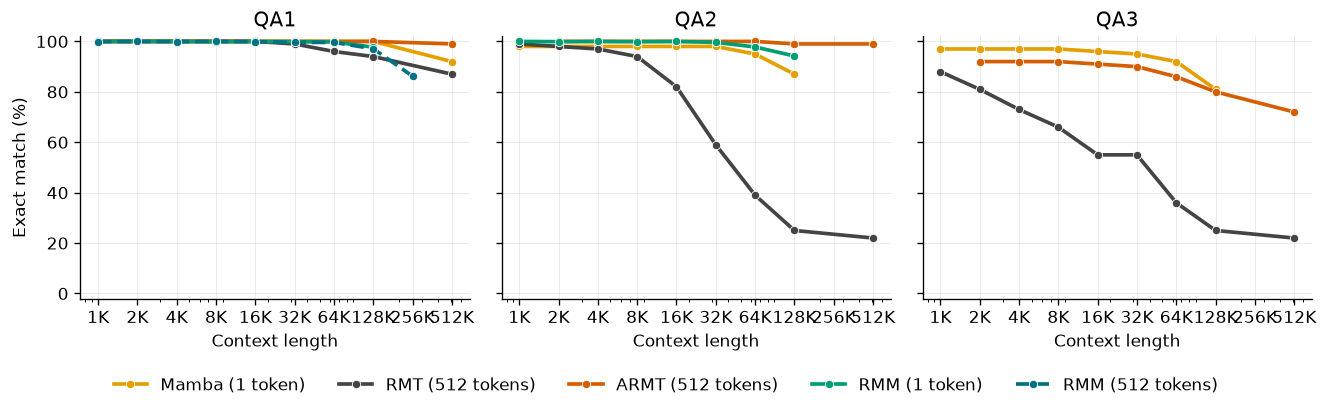

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
})

# Okabe-Ito palette (same mapping as efficiency_pareto.ipynb)
_BASE_COLOR = {
    'Mamba': '#E69F00',   # GDN / SSM orange
    'RMT': '#444444',     # self-attn grey
    'ARMT': '#D55E00',
    'RMM': '#009E73',     # rmm-parallel; mem 512 -> #007282 dashed
}

def _bench_context_tokens(col):
    k = _bench_col_to_k(col)
    return None if k <= 0 else int(k * 1000)

def _bench_series_style(method, mem):
    mem = int(mem)
    if method == 'RMM' and mem == 512:
        return dict(color='#007282', linestyle='--', marker='o')
    return dict(color=_BASE_COLOR[method], linestyle='-', marker='o')

def _bench_series_label(method, mem):
    mem = int(mem)
    tok = f'{mem} token' + ('s' if mem != 1 else '')
    return f'{method} ({tok})'

def _bench_xy(row, context_cols):
    xs, ys = [], []
    for c in context_cols:
        x = _bench_context_tokens(c)
        if x is None:
            continue
        v = row[c]
        if v is None or (isinstance(v, float) and pd.isna(v)):
            continue
        xs.append(x)
        ys.append(float(v))
    return xs, ys

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.4), sharey=True)
tick_ks = [k for k in (1, 2, 4, 8, 16, 32, 64, 128, 256, 512)
           if k <= _bench_col_to_k(CONTEXT_COLS[-1])]

for ax, task in zip(axes, ['qa1', 'qa2', 'qa3']):
    part = bench_df[bench_df.task == task]
    for _, row in part.iterrows():
        xs, ys = _bench_xy(row, CONTEXT_COLS)
        if len(xs) < 2:
            continue
        st = _bench_series_style(row['method'], row['mem_update_tokens'])
        ax.plot(xs, ys, lw=2.2, markersize=5,
                markeredgecolor='white', markeredgewidth=0.5, **st)
    ax.set_xscale('log')
    ax.set_xticks([k * 1000 for k in tick_ks])
    ax.set_xticklabels([f'{k}K' for k in tick_ks])
    ax.set_xlabel('Context length')
    ax.set_title(task.upper())
    ax.set_ylim(-2, 102)

axes[0].set_ylabel('Exact match (%)')

legend_rows = []
seen = set()
for _, row in bench_df.iterrows():
    key = (row['method'], int(row['mem_update_tokens']))
    if key in seen:
        continue
    xs, _ = _bench_xy(row, CONTEXT_COLS)
    if not xs:
        continue
    seen.add(key)
    legend_rows.append(key)
order = {'Mamba': 0, 'RMT': 1, 'ARMT': 2, 'RMM': 3}
legend_rows.sort(key=lambda k: (order.get(k[0], 9), k[1]))
handles = [
    Line2D([0], [0], lw=2.2, markersize=5, markeredgecolor='white', markeredgewidth=0.5,
           label=_bench_series_label(m, mem), **_bench_series_style(m, mem))
    for m, mem in legend_rows
]
fig.legend(handles=handles, loc='lower center', ncol=min(len(handles), 5),
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.08, 1, 1))

out_plot_pdf = REPO / 'notebooks' / 'results_babilong_accuracy.pdf'
out_plot_png = REPO / 'notebooks' / 'results_babilong_accuracy.png'
fig.savefig(out_plot_pdf, bbox_inches='tight')
fig.savefig(out_plot_png, dpi=150, bbox_inches='tight')
print('wrote', out_plot_pdf, 'and', out_plot_png)
plt.show()


## Markdown tables + export

Prints copy-pasteable markdown and writes `results_babilong.md`, `results_babilong.csv` (run-level), and `results_babilong_comparison.csv` (qa1–qa3 benchmark table) next to this notebook. LaTeX: run the following cell for `results_babilong_comparison.tex`.

In [30]:
parts = ['# BABILong RMM v5p7 results\n']
if eval_em is not None:
    parts += ['## Length-extrapolation eval (exact_match)\n', to_md(eval_em), '']
if train_em is not None:
    parts += ['## Training curriculum (exact_match)\n', to_md(train_em), '']
parts += ['## BABILong benchmark comparison (qa1–qa3)\n', bench_to_md(bench_df), '']
md = '\n'.join(parts)
print(md)

out_md = REPO / 'notebooks' / 'results_babilong.md'
out_csv = REPO / 'notebooks' / 'results_babilong.csv'
out_bench_csv = REPO / 'notebooks' / 'results_babilong_comparison.csv'
out_md.write_text(md)
df.to_csv(out_csv, index=False)
bench_df.to_csv(out_bench_csv, index=False)
print('\nwrote', out_md, out_csv, 'and', out_bench_csv)


# BABILong RMM v5p7 results

## Length-extrapolation eval (exact_match)

| task | variant | src | 0.5k | 1k | 2k | 4k | 8k | 16k | 32k | 64k | 128k | 256k |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| qa1 | identity/identity mem16 ss32 lr1e-03 | 32 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 0.991 | 0.980 | 0.948 |  |
| qa1 | identity/identity mem16 ss32 lr1e-04 | 32 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 0.971 | 0.838 |
| qa1 | identity/identity mem16 ss32 lr3e-04 | 32 | 1.000 | 1.000 | 1.000 | 1.000 | 0.999 | 1.000 | 0.999 | 0.998 | 0.977 |  |
| qa1 | pool/unpool mem16 ss32 lr1e-04 | 32 | 0.999 | 0.999 | 1.000 | 0.999 | 1.000 | 0.999 | 0.996 | 0.996 | 0.971 | 0.862 |
| qa2 | identity/identity mem16 ss32 lr1e-04 | 32 | 1.000 | 1.000 | 0.999 | 1.000 | 0.999 | 1.000 | 0.996 | 0.978 | 0.942 |  |
| qa2 | identity/identity mem16 ss32 lr3e-04 | 32 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 1.000 | 0.999 | 0.996 | 0.941 | 0.774 |

## Training curri

## LaTeX export (benchmark table)

Copy-paste into your paper (needs `\\usepackage{booktabs}`). Respects `TABLE_MAX_LENGTH` via `bench_df`.

In [31]:
bench_latex = bench_to_latex(bench_df)
print(bench_latex)

out_tex = REPO / 'notebooks' / 'results_babilong_comparison.tex'
out_tex.write_text(bench_latex + '\n')
print('wrote', out_tex)


\begin{tabular}{lllccccccccccc}
\toprule
Task & Model & Mem upd. & $0$K & $1\mathrm{K}$ & $2\mathrm{K}$ & $4\mathrm{K}$ & $8\mathrm{K}$ & $16\mathrm{K}$ & $32\mathrm{K}$ & $64\mathrm{K}$ & $128\mathrm{K}$ & $256\mathrm{K}$ & $512\mathrm{K}$ \\\\
\midrule
qa1 & Mamba & 1 token & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & --- & 92.0 \\\\
qa1 & RMT & 512 tokens & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 99.0 & 96.0 & 94.0 & --- & 87.0 \\\\
qa1 & ARMT & 512 tokens & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & 100.0 & --- & 99.0 \\\\
qa1 & RMM & 1 token & 100.0 & 100.0 & 100.0 & 100.0 & 99.9 & 100.0 & 99.9 & 99.8 & 97.7 & --- & --- \\\\
qa1 & RMM & 512 tokens & 99.9 & 99.9 & 100.0 & 99.9 & 100.0 & 99.9 & 99.6 & 99.6 & 97.1 & 86.2 & --- \\\\
\midrule
qa2 & Mamba & 1 token & 98.0 & 98.0 & 98.0 & 98.0 & 98.0 & 98.0 & 98.0 & 95.0 & 87.0 & --- & --- \\\\
qa2 & RMT & 512 tokens & 100.0 & 99.0 & 98.0 & 97.0 & 94.0 & 82.0 & 59.0 & 39.0 & 25.0 